# Projet numérique : choix du pas de temps
*Sebastian PARTARRIEU* &
*Antoine DEJOIE*

In [2]:
import numpy as np
import matplotlib.pyplot as plt


## Pas fixe 
### Euler explicite, méthode d'ordre 1
On implémente le schéma d'Euler explicite pour une fonction $x : \Re \longrightarrow \Re ^n$ qui peut donc être à valeur vectorielle. Le code utilise ainsi le module numpy. Le code renvoie le tableau temps et deux tableaux des vecteurs $x_j$ et $t_j$.

In [3]:
def solve_euler_explicit(f, x0, dt, T, t0 = 0):
    '''
    La fonction code la méthode d'euler explicite pour résoudre différentes équations différentielles. 
    Les fonctions prises en entrée peuvent prendre des valeurs vectorielles. On renvoie deux vecteurs, le vecteur temps et le vecteur solution
    On ajoute le temps T pour pouvoir définir l'intervalle [0,T] sur lequel on va résoudre l'équation différentielle. 
    '''
    n = int(T/dt)
    x, t = [0 for _ in range(n+1)], np.zeros(n+1)  #on travaille en numpy dans le cas ou f a valeurs vectorielles 
    x[0], t[0] = x0, t0                                                                                        #on pourrait utiliser np.arange pour le array des temps
    for i in range(n):
        t[i+1] = t[i] + dt
        x[i+1] = x[i] + dt*f(t[i], x[i])
    return t, x

On souhaite ensuite illustrer la convergence du schéma, qui a été démontrée en PC, sur un exemple où l'on connaît la solution analytique de l'équation différentielle $ f(t, x) = \dot{x}$. Prennons comme exemple tout d'abord, $f(t, x) = 5x$. La solution analytique est bien connue, il s'agit de $x : t \mapsto e^{5t}$, nous avons pris ici $x : \Re \longrightarrow \Re$ mais le code fonctionne avec un exemple a valeur vectorielle tant que f renvoi un array numpy.

In [4]:
def f(t, x):
    return 5*x

Pour illustrer la convergence d'un schéma de manière automatisée, on a écrit une fonction qui prend une méthode donnée, les arguments nécessaires pour que la méthode puisse être implémentée, la solution analytique et qui renvoie un tableau avec les $ \max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert$ pour plusieurs $dt$ choisis. Ici on a pris assez arbitrairement des dt qui se divisent par 10 à chaque itération jusqu'a un certain seuil, juste pour illustrer qu'on a bien $\lim\limits_{\Delta t \rightarrow 0} \max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert = 0$.
Nous avons aussi fait en sorte que la fonction trace la solution analytique et la solution approximée à chaque pas, donc pour chaque $dt$.

In [5]:
def illustrer_convergence(methode, f, x0, dt, T, analytique,  precision):
    '''
    Cette fonction prend en entrée une méthode choisie, les bons paramètres qui permettent de sortir un résultat 
    et la fonction analytique (en numpy - on utilisera np.vectorize le cas échéant) qui est solution de l'équation différentielle sur laquelle on teste la convergence de notre méthode. 
    On demande aussi la precision en dessous de laquelle l'utilisateur est satisfait qu'il y a effectivement convergence de notre méthode numérique. La précision porte sur le max des erreurs locales.
    t0 = 0 pris ici mais facilement modifiable en le passant en paramètre
    '''
    analytique = np.vectorize(analytique) 
    ecart = 1 
    dt_changing = dt
    dt_tab = []
    tab_ecart = []
    while precision <= ecart and dt_changing >= 10**(-5):  #pour ne pas avoir une boucle qui tourne à l'infini
        n = int(T/dt_changing)
        t, x_approx = methode(f, x0, dt_changing, T)
        x_true = analytique(t)
        val_absolue = np.vectorize(abs)
        erreur = val_absolue(x_true - x_approx)
        ecart = max(erreur)
        tab_ecart.append(ecart)
        dt_tab.append(dt_changing)
        plt.plot(t, x_approx)
        plt.plot(t, x_true)
        plt.legend(['x_approx', 'x_analytique'], loc = 'upper left')
        plt.title(f"Solution numérique et analytique f(t, x) = 5x, dt = {dt_changing}")
        plt.xlabel('t')
        plt.ylabel('x(t)')
        plt.show()
        dt_changing = dt_changing/10
    return tab_ecart, dt_tab

On prend ici la solution analytique de notre équation différentielle. L'appel a notre fonction illustrer_convergence permet donc de tracer les solutions numériques pour chaque dt et la solution analytique en même temps que nous donner le tableau décrit ci-dessus. Pour illustrer la convergence nous avons choisi de prendre une échelle des abscisses logarithmique pour accompagner le fait que l'on a choisit de diviser dt par 10 à chaque itération. Ainsi lorsque $dt \rightarrow 0$ on a $log(dt) \rightarrow -\infty$ qui explique donc l'axe des abscisses affiche des valeurs négatives.

In [6]:
def f1(x):
    return np.exp(5*x)

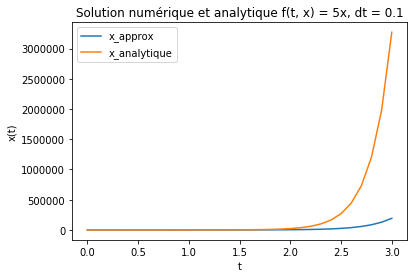

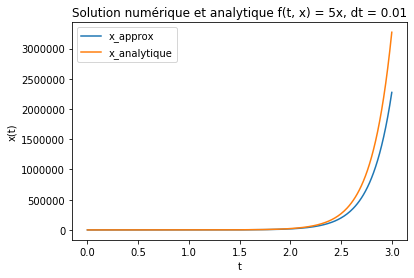

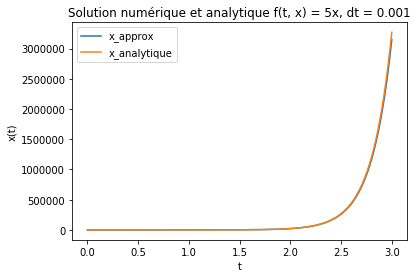

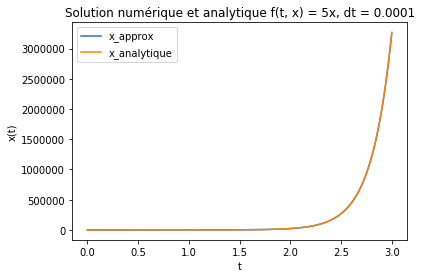

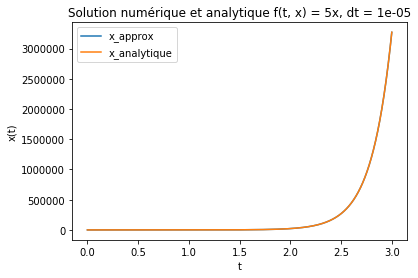

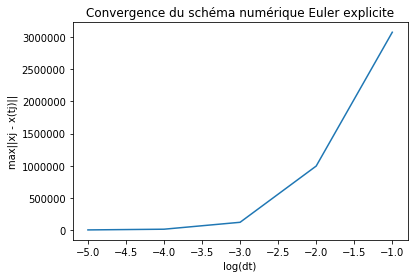

In [7]:
tab, dt_tab = illustrer_convergence(solve_euler_explicit, f, 1, 0.1, 3, f1, 0.01 )
plt.plot(np.log10(dt_tab), tab)
plt.title("Convergence du schéma numérique Euler explicite")
plt.xlabel("log(dt)")
plt.ylabel("max||xj - x(tj)||")
plt.show()

On a donc illustré la convergence du schéma de Euler. Reste à montrer qu'il s'agit bien d'une convergence  *d'ordre 1*  , on essaie donc de montrer que $\max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert \leq c_{v}(\Delta t)$ donc que pour $\Delta t > 0$ on a $\frac{\max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert}{\Delta t} \leq c_{v}$.
Pour cela on trace tout simplement le graphe des $\frac{\max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert}{\Delta t}$ pour les $\Delta t$ choisis avant.

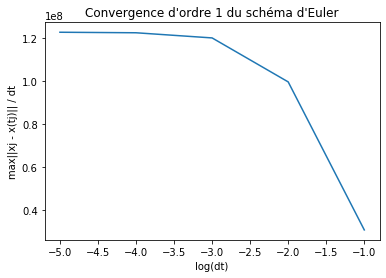

In [8]:
tab_new = np.array(tab)
dt_new = np.array(dt_tab)
tab_new = tab_new/dt_new
plt.plot(np.log10(dt_new), tab_new)
plt.title("Convergence d'ordre 1 du schéma d'Euler")
plt.xlabel("log(dt)")
plt.ylabel("max||xj - x(tj)|| / dt")
plt.show()

On voit donc bien que lorsque $\Delta t \rightarrow 0$, donc que $\log(\Delta t) \rightarrow -\infty$ le rapport tend vers une constante, ainsi on a bien la convergence *d'ordre 1*.

#### Les limites d'Euler d'ordre 1
Pour illustrer les limites du schéma implémenté, montrons que l'énergie ne se conserve pas lorsqu'on résout une simple équation d'oscillateur comme une équation différentielle d'ordre 1 sur un vecteur a deux dimensions. Si on fixe le pas de temps à une valeur "raisonnable" en terme de temps d'exécution de notre algorithme, résoudre notre équation sur un temps assez long donne une énergie qui finira toujours par se modifier. 



In [9]:
def g(t, X):
    '''
    pulsation du pendule vaut 1
    '''
    return np.array([X[1], -X[0]])

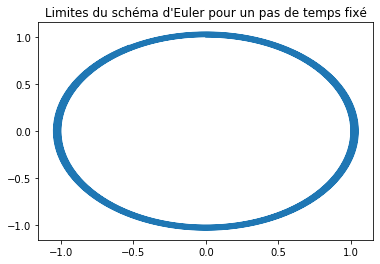

In [10]:
t, x = solve_euler_explicit(g, [0,1], 0.001, 100)
pos = [a[0] for a in x]
vit = [a[1] for a in x]
plt.plot(pos, vit)
plt.title("Limites du schéma d'Euler pour un pas de temps fixé")
plt.show()


### Heun, méthode d'ordre 2

On implémente maintenant le schéma de Heun, qui est d'ordre 2 et on effectue la même démarche pour illustrer la convergence de ce schéma, en utilisant de nouveau notre fonction illustrer_convergence.
On implémente le schéma sur le même exemple ou l'on connaît la solution analytique qui est une exponentielle.

In [11]:
def Heun(f, x0, dt, T):
    '''
    En supposant que la méthode de Heun est d'ordre 2
    '''
    t0, n = 0, int(T/dt)
    x, t = [0 for _ in range(n+1)], np.zeros(n+1) 
    x[0], t[0] = x0, t0
    for i in range(n):
        t[i+1] = t[i] + dt 
        x[i+1] = x[i] + (dt/2)*(f(t[i], x[i]) + f(t[i+1], x[i] + dt*f(t[i], x[i])))
    return t, x

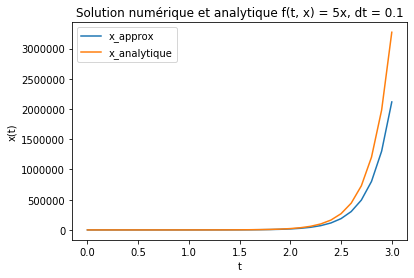

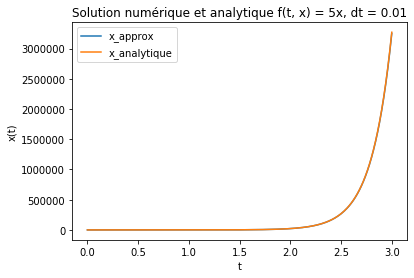

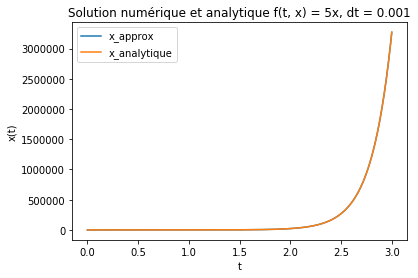

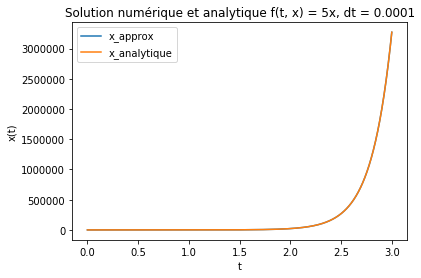

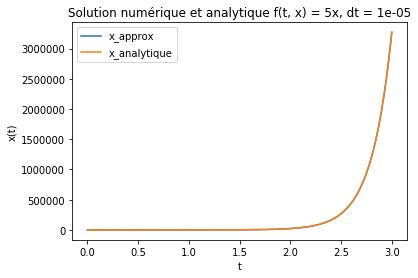

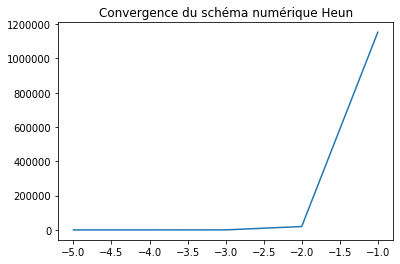

In [12]:
tab2, dt_tab2 = illustrer_convergence(Heun, f, 1, 0.1, 3, f1, 0.01)
plt.plot(np.log10(dt_tab2), tab2)
plt.title("Convergence du schéma numérique Heun")
plt.show()

On a donc illustré la convergence du schéma de Heun. Reste à montrer que c'est une convergence *d'ordre 2* et qu'on a donc $\frac{\max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert}{\Delta t ^2} \leq c_{v}$ pour ce schéma.
Comme pour Euler, on trace le graphe de $\frac{\max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert}{\Delta t ^2}$ pour les $\Delta t$ choisis avant lors de l'illustration de la convergence.

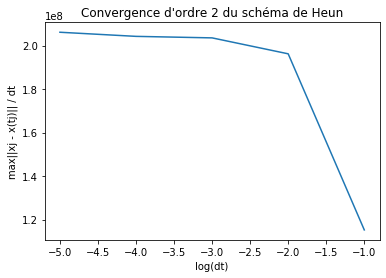

In [13]:
tab_new_2 = np.array(tab2)
dt_new_2 = np.array(dt_tab2)
dt_new_2 = dt_new_2**2
tab_new = tab_new_2/dt_new_2
plt.plot(np.log10(dt_new), tab_new)
plt.title("Convergence d'ordre 2 du schéma de Heun")
plt.xlabel("log(dt)")
plt.ylabel("max||xj - x(tj)|| / dt")
plt.show()

On voit bien que le rapport converge vers une valeur finie qui justifie donc que notre schéma est bien d'ordre 2

#### Limites du schéma de Heun
Effectuons la même démarche qu'avec Euler, regardons si l'énergie reste constante pour un pendule simple. Choisissons de même un pas de temps suffisament petit mais "raisonnable" pour le temps d'exécution de notre algorithme. 

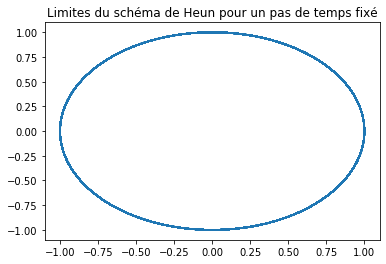

In [14]:
t, x = Heun(g, [0,1], 0.001, 1000)
pos = [a[0] for a in x]
vit = [a[1] for a in x]
plt.plot(pos, vit)
plt.title("Limites du schéma de Heun pour un pas de temps fixé")
plt.show()


Même sur un temps qui est 10 fois plus long que pour Euler, la méthode de Heun ne sembe pas montrer de grosse variation d'énergie lors de la résolution de l'équation différentielle. Cependant, l'on peut imaginer que sur des systèmes plus complexes ou sur des temps plus long, le schéma ne conserve pas l'énergie du système ce qui justifierait l'utilisation de schéma symplectique.
En deuxième lieu ceci nous ammène à la comparaison du schéma d'Euler et de Heun, on voit déjà que Heun est beaucoup plus précis sur l'équation différentielle régissant l'évolution de l'oscillateur.

#### Comparaison Euler et Heun
Pour comparer les deux méthodes, Euler et Heun, on peut déjà remarquer que pour un même $dt$ le schéma de Heun est beaucoup plus "proche" de la solution analytique que le schéma d'Euler. On peut ensuite quantifier ce sentiment en observant les graphes de convergence du schéma numérique. Pour les mêmes $\Delta t$ les valeurs des $\max\limits_{1 \leq j \leq J} \lVert x^{j} - x(t_{j}) \rVert$ pour Heun sont (a peu près d'un facteur 2) plus petites. Pour illustrer ceci, on peut tout simplement tracer sur le même graphe les courbes données par Heun et Euler pour un même pas de temps grossier

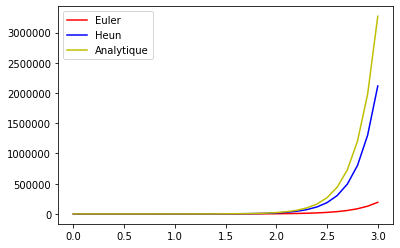

In [15]:
t1, x1 = solve_euler_explicit(f, 1, 0.1, 3)
t2, x2 = Heun(f, 1, 0.1, 3)
plt.plot(t1, x1, c = 'r')
plt.plot(t2, x2, c = 'b')
plt.plot(t1, np.exp(5*t1), c = 'y')
plt.legend(['Euler', 'Heun', 'Analytique'], loc = 'upper left')
plt.show()

## Adaptation du pas de temps

Reprennons les notations de l'énoncé. On a donc $f(t, x) = \dot{x}$ avec f une fonction $C^1$.
On a $x(t_{j+1}) = x^{j} + \int_{t_{j}}^{t_{j+1}}f(s, x(s))ds$ où x est solution de l'équation différentielle ci-dessus initialisée en $x^{j}$ à $t_{j}$ prise en $t_{j+1}$. On a donc $x(t_{j}) = x^{j}$.

Or on a aussi $x(t_{j+1}) = x(t_{j}) + \dot{x(t_{j})}\Delta t_{j} + \ddot{x(t_{j})} \frac{\Delta t_{j}^2}{2} + O(\Delta t_{j}^3)$, ceci étant valable vu que f est $C^1$ donc x est $C^2$. Ce qui se réecrit $x(t_{j+1}) = x(t_{j}) + f(t_{j}, x^j)\Delta t_{j} + \frac{d}{dt}f(t_{j}, x^{j}) \frac{\Delta t_{j}^2}{2} + O(\Delta t_{j}^3)$.
On reconnaît donc $x^{j+1} = x(t_{j}) + f(t_{j}, x^j)\Delta t_{j}$ pour notre schéma d'Euler.

Ainsi, $e^{j+1} = x(t_{j+1}) - x^{j+1} = \frac{d}{dt}f(t_{j}, x^{j}) \frac{\Delta t_{j}^2}{2} + O(\Delta t_{j}^3)$.

Par ailleurs, on a $f(t_{j+1}, x^{j+1}) =  f(t_{j}, x^{j}) + df(t_{j}, x^{j}).(\Delta t_{j},  x^{j+1} - x^{j}) + O(\Delta t_{j}^2)$, f étant $C^1$. D'où $f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j}) = \Delta t_{j} \partial_{t}f(t_{j}, x^{j}) + \Delta t_{j} f(t_{j}, x^{j}) \partial_{x} f(t_{j}, x^{j}) + O(\Delta t_{j}^2) = \Delta t_{j} \frac{d}{dt}f(t_{j}, x^{j}) + O(\Delta t_{j}^2)$ en utilisant la règle de la chaîne et le fait que $f(t, x) = \dot{x}$.

Finalement, on retrouve bien $\lVert e^{j+1} \rVert = \frac{\Delta t_{j}}{2}\lVert f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j})\rVert + O(\Delta t_{j}^3)$


#### Nouveau pas de temps
En reprennant, $e^{j+1} = \frac{\Delta t_{j}}{2}(f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j}))+ O(\Delta t_{j}^3)$. Il suffit donc de justifier que le terme $\frac{\Delta t_{j}}{2}(f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j})) =  O(\Delta t_{j}^2) $ donc que $f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j}) = O(\Delta t_{j})$ ce qui est vrai car $f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j}) = \Delta t_{j} \frac{d}{dt}f(t_{j}, x^{j}) + O(\Delta t_{j}^2)$ et que f est $C^1$ donc la dérivée est bornée sur l'intervalle compact $[0,T]$ sur lequel on résout notre équation différentielle. 


Justifions donc maintenant le choix de $\Delta t_{new} = \Delta t_{j} \sqrt{\frac{Tol_{abs}}{\lVert e_{j+1} \rVert}}$.
Ecrivons $e^{j+1} = M_{j} \Delta t_{j}^2 + O(\Delta t_{j}^3)$, avec $M_{j} = \frac{1}{2}\frac{d}{dt}f(t_{j}, x^{j})$.
On a $e^{j+2} = M_{j+1} \Delta t_{j+1}^2 + O(\Delta t_{j+1}^3)$.

Or, comme on a $M_{j+1} = M_{j}$ à l'ordre 1, on obtient $e^{j+2} = M_{j} \Delta t_{j+1}^2$ en restant à l'ordre le plus bas. D'où on obtient $e^{j+2} = \frac{e^{j+1}}{\Delta t_{j}^2} \Delta t_{j+1}^2$. Or en prennant le cas où $e^{j+2} = Tol_{abs}$ on obtient finalement $Tol_{abs} = \frac{e^{j+1}}{\Delta t_{j}^2} \Delta t_{j+1}^2$ D'où $\Delta t_{j+1} = \Delta t_{new} = \Delta t_{j} \sqrt{\frac{Tol_{abs}}{\lVert e_{j+1} \rVert}}$

#### Solveur a pas variable

Tout d'abord recopions le code fourni. Il s'agit d'expliquer puis d'illustrer son fonctionnement.

In [26]:
def solve_ivp_euler_explicit_variable_step(f, t0, x0, t_f, dtmin = 1e-16, dtmax = 0.01, atol = 1e-6):
    '''
    C'est le même algorithme, on c'est permis de rajouter un compteur pour illustrer son fonctionnement
    '''
    dt = dtmax/10; # initial integration step
    ts, xs = [t0], [x0]  # storage variables
    t = t0
    ti = 0  # internal time keeping track of time since latest storage point : must remain below dtmax
    x = x0
    compteur = []
    while ts[-1] < t_f:
        i = 0
        while ti < dtmax:
            i += 1
            t_next, ti_next, x_next = t + dt, ti + dt, x + dt * f(x)
            x_back = x_next - dt * f(x_next)
            ratio_abs_error = atol / (np.linalg.norm(x_back-x)/2)
            dt = 0.9 * dt * np.sqrt(ratio_abs_error)
            if dt < dtmin:
                raise ValueError("Time step below minimum")
            elif dt > dtmax/2:
                dt = dtmax/2
            t, ti, x = t_next, ti_next, x_next
        dt2DT = dtmax - ti # time left to dtmax
        t_next, ti_next, x_next = t + dt2DT, 0, x + dt2DT * f(x)
        ts = np.vstack([ts,t_next])
        xs = np.vstack([xs,x_next])
        t, ti, x = t_next, ti_next, x_next
        compteur.append(i)
    return (ts, xs, compteur)

Expliquons ce code par comparaison avec un algorithme d'Euler explicit standard:
Dans l'algorithme standard le pas de temps, fixé, est dtmax défini par l'utilisateur du programme. L'intervalle de temps $[O,T]$ est subdivisé en intervalles de largeur dtmax.

On a choisit de garder une solution échantillonée à dtmax, ce qui donne donc en sortie des tableaux de même taille que les algorithmes à pas constant.
    
Ici, pour avoir une solution de l'équation différentielle plus précise on subdivise chaque intervalle de taille dtmax en plusieurs intervalles de tailles dt (attention celui-ci change au cours de la deuxième boucle while - ainsi ces intervalles ne sont pas tous de même longueur) avec la méthode du pas adaptatif selon la manière suivante  :

-On  "initialise" et ensuite on calcule dt à chaque pas ( $= \Delta t_{new}$ ) avec la formule de la question précedente (+ coéfficent de sécurité de 0.9). En effet (x_back - x)/2 = (dt/2)(f(x) - f(x_next)) ce qui correspond bien à $e^{j+1} = \frac{\Delta t_{j}}{2}(f(t_{j+1}, x^{j+1})  - f(t_{j}, x^{j}))+ O(\Delta t_{j}^3)$ en norme. Si ce $= \Delta t_{new}$ est inférieur d'une valeur seuil, on renvoie une erreur. On prend ensuite le $min(\Delta t_{new}, dtmax/2)$. Ceci permet d'assurer que l'on va effectuer au moins 2 itération de la boucle.

-On applique donc plusieurs itérations d'Euler explicite à l'intérieur d'un même intervalle de largeur dtmax avec un pas changeant selon notre formule. Ce qui est intéressant ici c'est donc que le nombre d'itérations du schéma d'Euler sur ces intervalles va changer selon l'erreur qu'on commet : en effet si on commet une grande erreur notre pas de temps à l'intérieur de la deuxième boucle while diminue et on va donc devoir faire plus d'itérations pour arriver a ti>=tmax.

-En sortie de la première boucle, on fait en sorte de garder le bon échantillonage pour notre solution finale en ajoutant le temps manquant (qui - on le repète - sera *a priori* différent pour les différents intervalles de largeur dtmax) et en effectuant la dernière itération d'Euler explicite. On réinitialise aussi ti a 0.

On stocke le tout et on renvoie.
        

#### Comparaison rapide avec Euler explicite

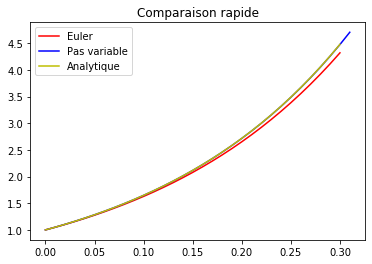

In [25]:
def f3(x):
    return 5*x

t_1, x_1 = solve_euler_explicit(f, 1, 0.01, 0.3)  #(f, x0, dt, T, t0 = 0)
t_2, x_2, compteur = solve_ivp_euler_explicit_variable_step(f3,0, 1,0.3) #(f, t0, x0, t_f, dtmin = 1e-16, dtmax = 0.01, atol = 1e-6):
plt.plot(t_1, x_1, c = 'r')
plt.plot(t_2, x_2, c = 'b')
plt.plot(t_1, np.exp(5*t_1), c = 'y')
plt.title("Comparaison rapide")
plt.legend(['Euler', 'Pas variable', 'Analytique'], loc = 'upper left')
plt.show()

On pourrait illustrer la convergence d'ordre 1 et 2 du schéma mais au vu des courbes celles-ci semblent évidente, par soucis de concision pour un notebook qui devient déjà long on a choisi de regarder le nombre de pas plutôt qur d'illustrer la convergence de cette méthode qui marche clairement mieux que les méthodes à pas constants.

#### Le nombre de pas est bien variable
On voit d'ailleurs que le nombre d'itération effectué sur un intervalle de longueur dtmax change bien au cours du temps, on remarque que pour notre exemple ce nombre augmente au cours du temps. Mais ceci n'est pas général, comme le montre le deuxième exemple.

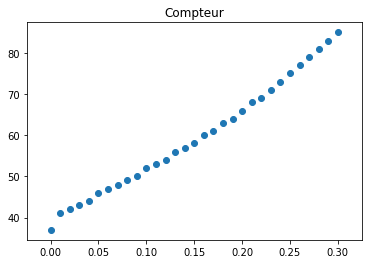

In [40]:
plt.scatter(t_1, compteur)
plt.title("Compteur")
plt.show()

In [35]:
def g_2(X):
    return np.array([X[1], -X[0]])

Text(0.5, 1.0, 'Compteur pour un oscillateur')

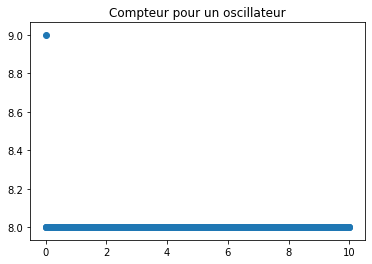

In [56]:
t_3, x_3, compteur_2 = solve_ivp_euler_explicit_variable_step(g_2, 0, np.array([0,1]), 10)
plt.scatter([i*0.01 for i in range(len(compteur_2))], compteur_2)
plt.title("Compteur pour un oscillateur")

On voit ici que pour l'oscillateur, hormis la première valeur qui est dû à l'initialisation de dt, on a toujours 8 itérations de l'algorithme sur les intervalles de longueur dtmax. Le pas de temps s'adapte effectivement au problème. 

## Fin du notebook 